Clean up my method for running MCMC

In [19]:
import eMCMC
import importlib
import eplots
Plotter = eplots.Plotting()
import estats
from matplotlib.ticker import MaxNLocator
from IPython.display import display, Math
from scipy.stats import mode

In [20]:
# Get data
datBouw21 = np.loadtxt('/Users/eb35267/Desktop/research/data/Bouwens2021_GAL.txt',  skiprows=2, unpack=True)
redshiftsBouw21 = np.unique(datBouw21[0])
dredshiftsBouw21 = np.ones_like(redshiftsBouw21)/2. #approximate, there are true window functions to use

datHST = [] 
#format is     zdat = data[0] zerr = data[1] xdat = data[2],  ydat = data[3]  yerr = data[4]  xerr = data[5] 

for iz,z in enumerate(redshiftsBouw21): # Create a bunch of arrays that contain all of the data listed above. One for each redshift
    zlistindex = datBouw21[0] == 1.0*z
    datarr = [z,dredshiftsBouw21[iz], datBouw21[1][zlistindex], datBouw21[3][zlistindex], datBouw21[4][zlistindex], datBouw21[2][zlistindex]]
    datHST= datHST + [datarr]

In [21]:
# Plotting
# def compare_fits(alt_params, labels, samples, my_UVLF, data_label = 'Bouwens+21', Plotting = None, title = 'Fit comparison'):
#     """
#     samples [ndarray]: Results from MCMC
#     my_UVLF: MCMC_UVLF object
#     piecewise_flags [2darray]: whether the fits are piecewise or linear in epsilon & sigma
#     """
#     # Figure out how many subplots to make
#     zs = [dat[0] for dat in my_UVLF.data]
#     nz = len(zs)
#     fig, ax = plt.subplots(1, nz, sharey = True)
#     fig.set_size_inches(3.5*nz, 3)
#     plt.subplots_adjust(wspace = 0.1)

#     if Plotting is None:
#         Plotting = eplots.Plotting()

#     for i, (dat, z) in enumerate(zip(my_UVLF.data, zs)):
    
#         # Decompose the data
#         zdat = dat[0]
#         zerr = dat[1]
#         xdat = dat[2]
#         ydat = dat[3]
#         yerr = dat[4] 
#         xerr = dat[5]   

#         yerr = np.fmax(yerr, ydat* my_UVLF.MINRELERROR) # Make sure error bars aren't any smaller than the relative error set above

#         # Plot my best fit
#         best_fit = np.average(samples, axis = 0)
#         chi2 = -2*my_UVLF.log_like(best_fit)
#         ax[i].plot(xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,xdat,xerr, best_fit)), label = f'My fit (linear), $\chi^2 = {chi2:.0f}$', 
#                    zorder = 1)
        
#         # Plot other fit options
#         for params, label, ls in zip(alternative_fits, labels, ['--', 'dotted']):
#             chi2 = -2*my_UVLF.log_like(params)
#             ax[i].plot(xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,xdat,xerr, params)), label = f'{label}, $\chi^2 = {chi2:.0f}$', 
#                                       linestyle = ls)
    
#         ax[i].errorbar(xdat, np.log10(ydat), estats.calc_log_error(ydat, yerr), fmt = ".", capsize=0, markersize = 10, 
#                        color = Plotting.navy, label = data_label)
        
#         ax[i].invert_xaxis()
#         ax[i].set_ylim(np.log10(np.min(ydat))-1, np.log10(np.max(ydat))+2)
#         ax[i].set_xlim(np.max(xdat)+0.25, np.min(xdat)-0.25)
#         ax[i].set_title(f'$z \simeq {int(zdat)}$')
#         ax[i].xaxis.set_major_locator(MaxNLocator(integer=True)) # Make it so that only integers can be used in the axis labels

#     ax[0].set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
#     fig.text(.5, -0.05, r'$M_{\rm{UV}}$ [mag]', ha = 'center')
#     fig.text(.5, 1.1, title, ha = 'center', fontsize = 20)
#     leg = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

#     return fig

In [37]:
custom_params = {'dalphadz': {'fit': True}, 'dbetadz': {'fit':True}, 'dlogMcdz': {'fit': True}, 'dlogedz':{'fit': True}, 
               'dsigdz': {'fit': True}}#, 'dsigdM':{'fit': True, 'scale':100}}
param_data = eMCMC.build_param_data(custom_params)

In [40]:
importlib.reload(eMCMC)

<module 'eMCMC' from '/Users/eb35267/Desktop/research/escripts/eMCMC.py'>

In [41]:
# Initalize class
my_UVLF = eMCMC.UVLF(datHST, param_data)

In [42]:
# Get initial positions for all the walkers by running a short MCMC
ICs = my_UVLF.generate_ICs()

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [43]:
# Run MCMC
Nsteps=2000
my_UVLF.sampler.run_mcmc(ICs, Nsteps) 

State([[ 8.42230290e-01  3.23964023e-02 -3.66054997e-01  4.13414705e-01
   1.19409278e+01  4.25184505e-02 -7.77465431e-01  7.49424356e-03
   4.35369308e-01 -9.93048809e-02]
 [ 6.95220572e-01  5.81907065e-03 -5.70307491e-01  2.98836631e-01
   1.20123213e+01  7.41117472e-02 -8.97396693e-01 -1.29683125e-02
   6.07004919e-01 -5.71079591e-02]
 [ 7.00269780e-01 -1.14284375e-02 -6.92810337e-01  4.17005843e-01
   1.19690689e+01  3.68522626e-02 -9.56963520e-01 -5.86159062e-02
   6.09324789e-01 -2.43417856e-02]
 [ 6.99684547e-01  6.24895042e-04 -6.48746615e-01  1.97660920e-01
   1.23482439e+01  1.61846991e-01 -7.56221685e-01  2.71113306e-03
   6.29061856e-01 -1.69493698e-02]
 [ 7.04279277e-01  1.50718569e-02 -1.14537829e-01  1.84846272e-01
   1.21066593e+01  7.86714693e-02 -8.28676742e-01 -1.56440312e-02
   5.67525894e-01 -3.74509913e-02]
 [ 7.10747960e-01  6.51215219e-03 -1.44998471e-01  3.21705923e-01
   1.18309094e+01  3.74630391e-02 -9.48630726e-01 -2.36700930e-02
   5.50753003e-01 -7.353832

In [44]:
# Get a list of all of the parameter values along the chain
samples = my_UVLF.sampler.get_chain(discard = 400, flat=True) # No need to deal with scale here, it will be taken care of in the wrapper

In [45]:
# Time evolution plot
corner_plot = Plotter.plot_corner(samples, my_UVLF) # [1::2] means start at index 1 & step by 2s-- so, odd numbers

/Users/eb35267/Desktop/research/escripts/eplots.py:165: SyntaxWarning: invalid escape sequence '\s'
  ax[i].set_title(f'$z \simeq {int(zdat)}$')
/Users/eb35267/Desktop/research/escripts/eplots.py:218: SyntaxWarning: invalid escape sequence '\c'
  ax[i].plot(xdat, np.log10(currUVLF.UVLF_wrapper(zdat,zerr,xdat,xerr, sample)), label = f'{label}, $\chi^2 = {chi2:.0f}$',
/Users/eb35267/Desktop/research/escripts/eplots.py:224: SyntaxWarning: invalid escape sequence '\s'
  ax[i].set_title(f'$z \simeq {int(zdat)}$')


KeyError: 'scale'

In [10]:
# # Plot epsilon & sigma central values
# corner_plot = Plotter.plot_corner(samples[:,[6,8]], [labels[6], labels[8]])
# #corner_plot.savefig('/Users/eb35267/Desktop/figures/ongoing/evolving_UVLF/corner_sig_eps.png', bbox_inches='tight')

/Users/eb35267/miniconda3/envs/research/lib/python3.12/site-packages/zeus21/UVLFs.py:29: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


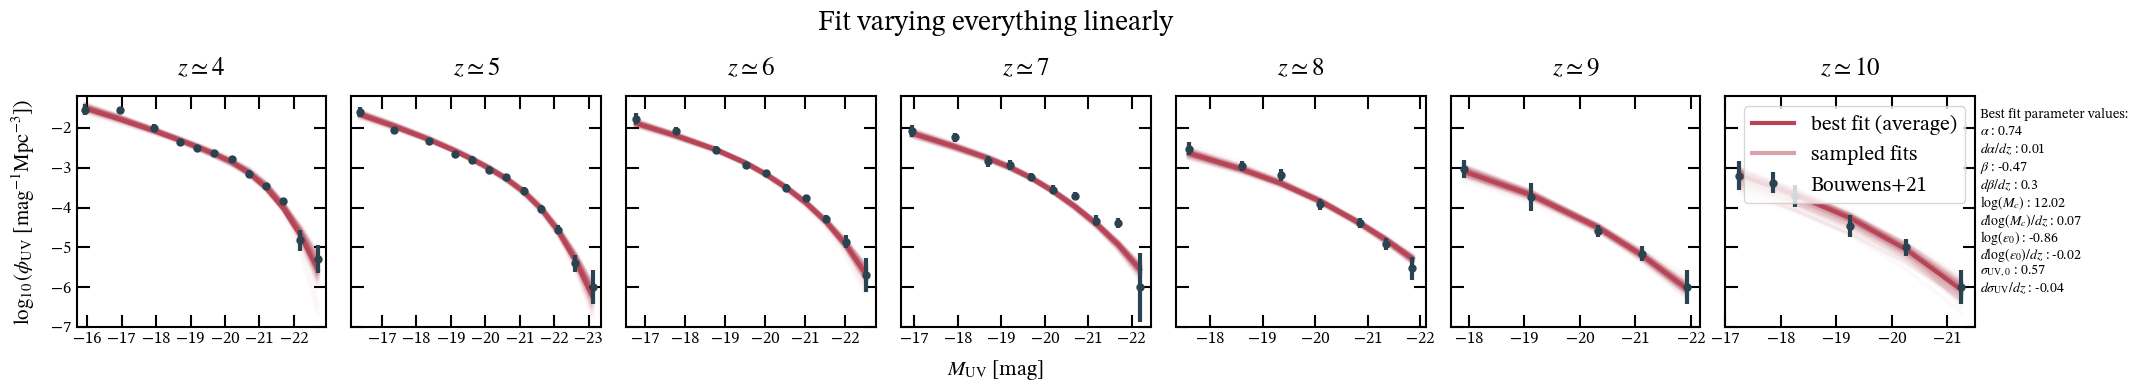

In [29]:
# Look at the fit over time
comp_fig = Plotter.plot_evolving_UVLF_fit(samples, my_UVLF, title = r'Fit varying everything linearly', nsamples = 100)
#comp_fig.savefig('/Users/eb35267/Desktop/figures/ongoing/evolving_UVLF/Bouwens_over_time.png', bbox_inches='tight')

In [12]:
# def UVLF_fit_single_z(samples, z, my_UVLF, bf_type = 'average', data_label = 'Bouwens+21', Plotting = None, 
#                        nsamples = 100, truths = None, title = 'UVLF data vs. MCMC fit'):
#     """
#     samples [ndarray]: Results from MCMC
#     my_UVLF: MCMC_UVLF object
#     """
#     fig, ax = plt.subplots()

#     if Plotting is None:
#         Plotting = eplots.Plotting()

#     assert bf_type in ['average', 'mode'], 'The best fit type must be either average or mode'

#     # Choose random samples from the MCMC chain
#     inds = np.random.randint(len(samples), size=nsamples) # Choose nsamples from the chain

#     all_data = my_UVLF.data
#     zs = np.array([all_dat[0] for all_dat in all_data])
#     ind = np.where(zs == z)[0].item() # The .item() removes the brackets
    
#     # Decompose the data
#     zdat = all_data[ind][0]
#     zerr = all_data[ind][1]
#     xdat = all_data[ind][2]
#     ydat = all_data[ind][3]
#     yerr = all_data[ind][4] 
#     xerr = all_data[ind][5]   

#     yerr = np.fmax(yerr, ydat* my_UVLF.MINRELERROR) # Make sure error bars aren't any smaller than the relative error set above

#     # Plot each sample from the chain
#     for ind in inds:
#         sample = samples[ind]
#         ax.plot(xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,xdat,xerr, sample)), alpha=nsamples/3500, color = Plotting.red, 
#                    zorder = 0)
    
        
#     if truths is not None: # Plot the true curve if one is known. Otherwise, plot the best fit
#         ax.plot(xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,xdat,xerr, truths)), color = Plotting.red, label = 'true UVLF', 
#                    zorder = 1)
#     else: # Options for how to define best fit
#         if bf_type == 'mode':
#             best_fit = mode(samples, axis = 0).mode 
#         else:
#             best_fit = np.average(samples, axis = 0)
            
#     ax.plot(xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,xdat,xerr, best_fit)), color = Plotting.red, 
#                label = f'best fit ({bf_type})', zorder = 1)
    
#     ax.plot([0], [0], color = Plotting.red, alpha = 0.5, label = 'sampled fits') # Create the label for the samples
#     ax.errorbar(xdat, np.log10(ydat), estats.calc_log_error(ydat, yerr), fmt = ".", capsize=0, markersize = 10, 
#                    color = Plotting.navy, label = data_label)
        
#     ax.invert_xaxis()
#     ax.set_ylim(np.log10(np.min(ydat))-1, np.log10(np.max(ydat))+2)
#     ax.set_xlim(np.max(xdat)+0.25, np.min(xdat)-0.25)
#     ax.set_title(f'$z \simeq {int(zdat)}$')
#     ax.xaxis.set_major_locator(MaxNLocator(integer=True)) # Make it so that only integers can be used in the axis labels

#     ax.set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
#     ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')
#     fig.text(.5, 1, title, ha = 'center', fontsize = 20)
#     ax.legend()

#     return fig

In [13]:
# prior_effect = UVLF_fit_single_z(samples, 9, my_UVLF, title = '')

# #prior_effect.savefig('/Users/eb35267/Desktop/figures/ongoing/problems/bad_fits_prior_z9.png')

In [33]:
best_fits = [np.average(samples, axis = 0),
    [0.61, -0.01, -1.91, 0.08, 12.03, 0.03,
          [-0.835644487121554, -0.8813262539539082, -0.878982150926344, -1.0135562584726614, -1.1280360370537728, -1.1736330772706727,
            -1.170950067781292], 0,
           0.65, -0.03], # Scale all of the parameters the same way you did in the MCMC
          [.74, 0.03, -1.76, -0.02, 11.84, -0.02, -1.08, -0.07, 
           [0.7386363636363633, 0.7386363636363633, 0.7954545454545454, 0.6931818181818183, 0.43181818181818166, 0.4545454545454546, 
           0.5340909090909092], 0]
          ]
fit_labels = [r'My fit (linear)', r'Muñoz+23 HST($\epsilon_*$)', r'Muñoz+23 HST($\sigma_{\rm{UV}}$)']

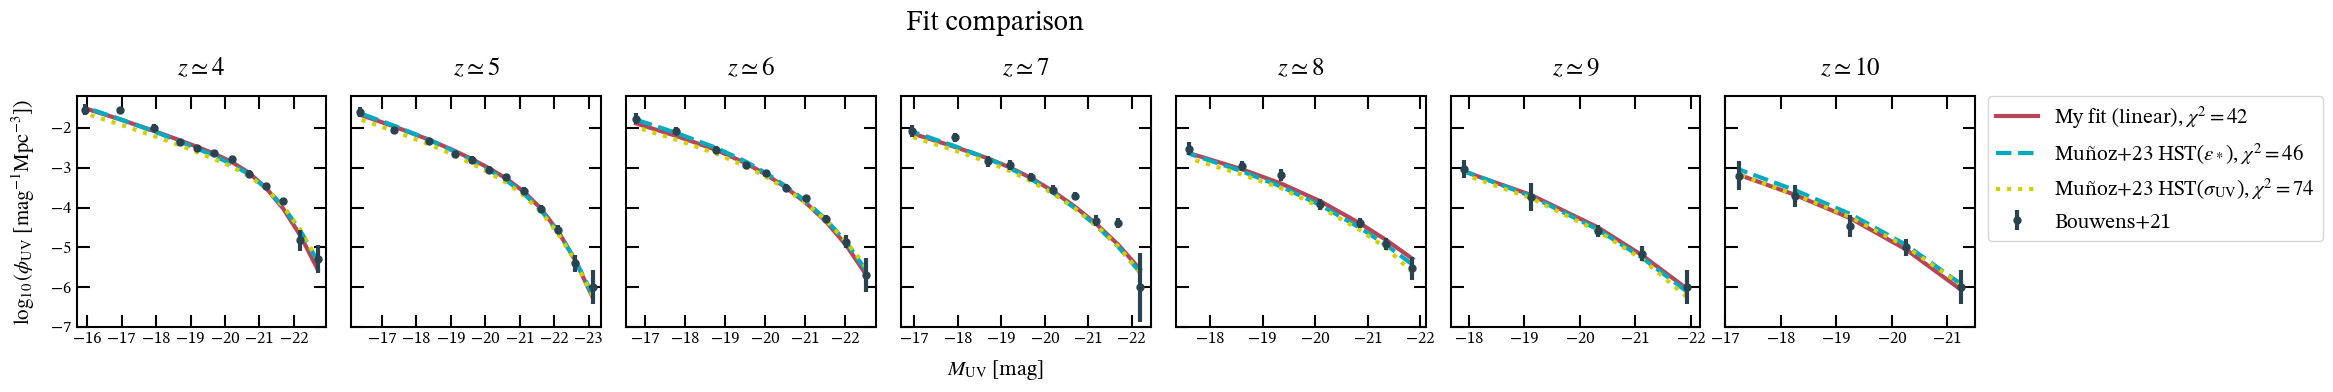

In [35]:
compare_fig = Plotting.compare_fits(datHST, best_fits, fit_labels, [my_UVLF, my_UVLF, my_UVLF])
#compare_fig.savefig('/Users/eb35267/Desktop/figures/ongoing/Muñoz_comparison/fit_comparison_muñoz.png', bbox_inches='tight')

In [304]:
[key for key, val in param_data.items() if val['fit']]

['alpha',
 'dalphadz',
 'beta',
 'dbetadz',
 'logMc',
 'dlogMcdz',
 'loge',
 'dlogedz',
 'sig',
 'dsigdz',
 'dsigdM']

Text(0.5, 0, 'redshift')

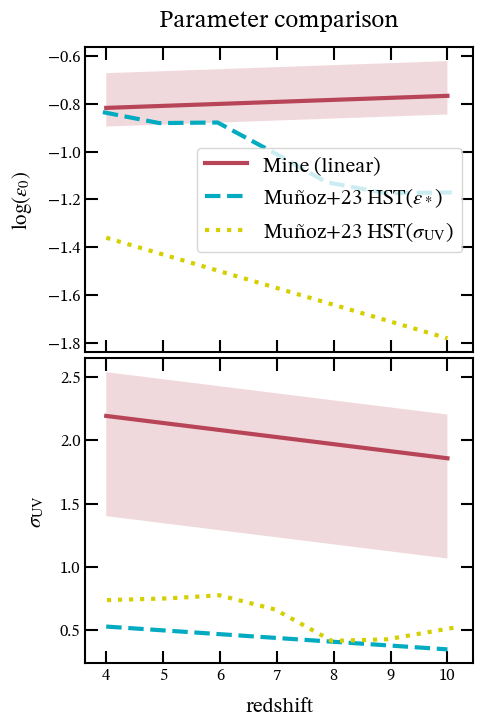

In [307]:
# jm_epsilon = np.array([3.940719611387257, -0.835644487121554,
# 4.9321057388160865, -0.8813262539539082,
# 5.95882286488929, -0.878982150926344,
# 7.01536375960235, -1.0135562584726614,
# 7.873220741075462, -1.1280360370537728,
# 8.901717126073203, -1.1736330772706727,
# 10.07687528242205, -1.170950067781292]).reshape(-1, 2)

# jm_sigma = np.array([4.012793027097318, 0.738633301702222,
# 5.076793308262749, 0.7520120901135203,
# 5.992408533370822, 0.7764734825853163,
# 6.969036656943029, 0.6646867934254148,
# 7.96956384212561, 0.41658173127613995,
# 8.946965170632271, 0.4297965065195233,
# 10.135170280813973, 0.522955985894868
# ]).reshape(-1, 2)


# fig, ax = plt.subplots(2, 1, sharex = True)
# fig.set_size_inches(5, 8)
# plt.subplots_adjust(hspace=0.02)
# ax[0].plot(redshiftsBouw21, best_fit[6] + (best_fit[7]*(redshiftsBouw21-8)), label = 'Mine (linear)')
# sigeps = np.std(samples[:,0])
# ax[0].fill_between(redshiftsBouw21,  best_fit[6]-sigeps + ((redshiftsBouw21-8)*best_fit[7]), 
#                    best_fit[6]+sigeps + (redshiftsBouw21*best_fit[7]), alpha = 0.2)
# ax[0].plot(jm_epsilon[:,0], jm_epsilon[:,1], linestyle = '--', label = r'Muñoz+23 HST($\epsilon_*$)')
# ax[0].plot(redshiftsBouw21,( -1.08 + (-0.07*redshiftsBouw21)), label = r'Muñoz+23 HST($\sigma_{\rm{UV}}$)', linestyle = 'dotted')
# ax[0].set_ylabel(labels[6])
# ax[0].legend()
# ax[0].set_title(r'Parameter comparison')

# ax[1].plot(redshiftsBouw21, best_fit[8] + (best_fit[9]*(redshiftsBouw21-8)))
# sigsig = np.std(samples[:,8])
# ax[1].fill_between(redshiftsBouw21,  best_fit[8]-sigsig + ((redshiftsBouw21-8)*best_fit[9]), 
#                    best_fit[8]+sigsig + (redshiftsBouw21*best_fit[9]), alpha = 0.2)
# ax[1].plot(redshiftsBouw21,(.65 + (-0.03*redshiftsBouw21)), linestyle = '--')
# ax[1].plot(jm_sigma[:,0], jm_sigma[:,1], linestyle = 'dotted')
# ax[1].set_ylabel(labels[8])
# ax[1].set_xlabel('redshift')

# #fig.savefig('/Users/eb35267/Desktop/figures/ongoing/evolving_UVLF/Muñoz+23_comp_errors.png', bbox_inches='tight')

In [547]:
save_dir

'/Users/eb35267/Desktop/figures'

In [132]:
test = {'1':{'hello': 1, 'hola': 2}, 
        '2': {'goodbye': 3, 'adios': 4}}

[{'hello': 1, 'hola': 2}, {'goodbye': 3, 'adios': 4}]

In [271]:
test = np.array([1, 2, 2, 3])

In [273]:
np.where(test == 2)[0]

array([1, 2])